In [66]:
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

#defining distance function between two points
def euclid_dist(p1,p2):
  dist = np.sqrt(np.sum((np.array(p1)-np.array(p2))**2))
  return dist

#defining knn prediction function
def knn_predict(training_data, training_labels, test_point, k):
  distances = []
  for i in range(len(training_data)):
    distances.append([euclid_dist(test_point,training_data[i]), training_labels[i]])
  distances.sort(key= lambda x: x[0])
  k_nearest= [item[1] for item in distances[0:k]]
  return Counter(k_nearest).most_common(1)[0][0]

#creating training data function
def training_data_generate(n,size): #n is number of types, size is number of points of each type
  if n>26:
    print('Too many types')
  else:
    letters = ['A','B','C','D','E','F','G','H','I','J','K','L','M','N','O','P','Q','R','S','T','U','V','W','X','Y','Z'] #up to 26 theoretical categories
    datapoints = []
    labels = []
    for letter in letters[:n]:
      xcentre = np.random.uniform(-10,10) #generate a random centre for each type of datapoint
      ycentre = np.random.uniform(-10,10)
      xpoints = np.random.normal(loc=xcentre, scale=3, size=size) #generate given number of data points around centre for each category
      ypoints = np.random.normal(loc=ycentre, scale=3, size=size)
      for i in range(size):
        datapoints.append((xpoints[i],ypoints[i]))
        labels.append(letter)
    return [datapoints,labels]





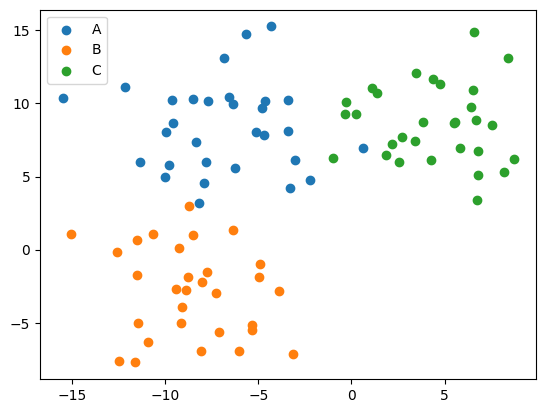

In [67]:
#next want to define a function that plots training data points with different colours

def plot_training_data(training_data,training_labels):
  unique_labels = sorted(list(set(training_labels))) # Sort unique labels alphabetically
  for label in unique_labels:
    xpoints = [training_data[i][0] for i,l in enumerate(training_labels) if l == label]
    ypoints = [training_data[i][1] for i,l in enumerate(training_labels) if l == label]
    plt.scatter(xpoints, ypoints, label = label)
  plt.legend()
  plt.show()

data1,labels1 = training_data_generate(3,30)
plot_training_data(data1,labels1)


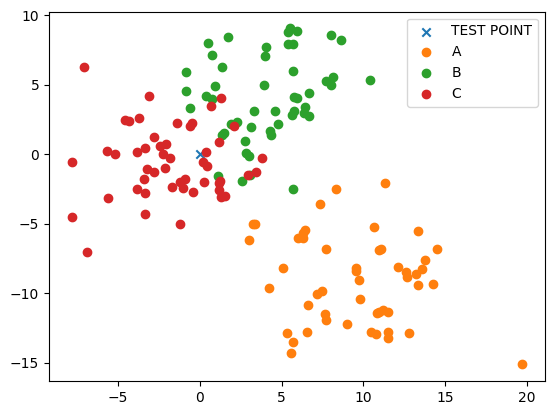

The data point is predicted to be category C


In [68]:
#finally a function that plots training data, plots test point and then runs k nearest and gives the result

def k_nearest_plot(training_data, training_labels, test_point, k):
  plt.scatter(test_point[0],test_point[1], marker = 'x', label = 'TEST POINT') #plot test point
  plot_training_data(training_data, training_labels) #plot training data
  prediction = knn_predict(training_data, training_labels, test_point, k) #run knn
  print(f'The data point is predicted to be category {prediction}')

data,labels = training_data_generate(3,50)
test = (0,0)
k_nearest_plot(data, labels, test, 5)